**Lab2-DL: C1-cnn-environment-architecture.ipynb** (BMED365) | Priority: 2 (recommended)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/C1-cnn-environment-architecture.ipynb)

# 🌸 C1: CNN Image Classification - Environment Setup and Architecture

Updated: 2025-12-22, 2026-01-15 A. Lundervold

**From Nature to Medicine: A Practical Introduction to Convolutional Neural Networks**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Understand CNN fundamentals** | Explain convolution, pooling, and why CNNs work for images |
| **Set up deep learning environment** | Configure PyTorch for CPU, GPU, or Apple Silicon (MPS) |
| **Handle image datasets** | Load, explore, and preprocess image data for training |
| **Build CNN architecture** | Create a convolutional neural network from scratch |
| **Connect to medical imaging** | See parallels between flower and medical image classification |

### What You Will Learn

In this notebook we will:
- **Understand** how CNNs work on images
- **Set up** the environment for training (CPU, GPU, MPS)
- **Explore** the flower dataset
- **Build** a CNN model from scratch
- **Prepare** for training in part 2

## Theoretical Foundation

### The Formalism y ~ f(X, θ)

In machine learning, we can express the classification problem as:

**y = f(X, θ) + ε**

Where:
- **y** = predicted class (flower type)
- **X** = input image (pixel values)
- **θ** = model parameters (CNN weights)
- **f** = non-linear function (the CNN architecture)
- **ε** = error term (noise)

This is identical to medical image analysis, just with different classes!

## Comparison: Natural vs Medical Images

| Aspect | Flower Classification | Medical Image Analysis |
|--------|------------------------|------------------------|
| **Input (X)** | RGB images of flowers | MRI, X-ray, CT scan |
| **Classes (y)** | Flower types | Disease states |
| **Complexity** | Color, shape, texture | Anatomical structures |
| **Consequences** | Aesthetic value | Healthy vs Sick |
| **Data volume** | Thousands of images | Limited (privacy) |
| **Expertise** | Botany | Medicine/radiology |

**Common principles:**
- Both require domain knowledge
- Both have problems with imbalanced classes  
- Both need robust models
- Both have ethical implications

## 🔧 Environment Setup

First, we need to ensure that all necessary libraries are installed and that we are using the correct device (CPU, GPU, or MPS).

In [3]:
import sys
import subprocess
import os

# Check if we are running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Running in Google Colab")
    
    # Install necessary packages
    %pip install seaborn --quiet
    
    # Check if the folder already exists
    if not os.path.exists('ELMED219-2026/Lab2-DL'):
        print("📥 Downloading course materials...")
        try:
            !git clone https://github.com/arvidl/BMED365-2026.git
            os.chdir('ELMED219-2026/Lab2-DL')
        except:
            print("❌ Could not download course materials")
            print("Download manually from: https://github.com/arvidl/BMED365-2026")
else:
    print("💻 Running locally")
    
print("✅ Environment setup complete!")

💻 Running locally
✅ Environment setup complete!


In [4]:
# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================

# === Deep Learning (PyTorch) ===
import torch                          # Core PyTorch (tensors, autograd)
import torch.nn as nn                 # Neural network layers
import torch.optim as optim           # Optimizers (SGD, Adam)
from torch.utils.data import Dataset, DataLoader  # Data handling

# === Image Processing ===
import torchvision.transforms as transforms  # Image transformations
from torchvision import datasets      # Standard datasets
from PIL import Image                 # Python Imaging Library

# === Scientific Computing & Visualization ===
import matplotlib.pyplot as plt       # Plotting
import numpy as np                    # Numerical arrays
import seaborn as sns                 # Statistical visualization
from pathlib import Path              # Cross-platform paths
import random                         # Random number generation

# === Machine Learning Utilities ===
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# REPRODUCIBILITY SETTINGS
# =============================================================================
# Setting seeds ensures consistent results across runs
# This is essential for debugging and scientific reproducibility

RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# For CUDA (if available)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("📚 Libraries imported!")
print(f"🎲 Random seed set to {RANDOM_SEED} for reproducibility")

📚 Libraries imported!
🎲 Random seed set to 42 for reproducibility


In [5]:
# Configure device (CPU, GPU, or MPS)
def setup_device():
    """Set up the best available device"""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"🚀 Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("🍎 Using MPS (Apple Silicon)")
    else:
        device = torch.device('cpu')
        print("💻 Using CPU")
    
    return device

device = setup_device()
print(f"✅ Device set to: {device}")

🍎 Using MPS (Apple Silicon)
✅ Device set to: mps


## 🌸 Dataset Setup

We use the [Flowers Recognition Dataset](https://www.kaggle.com/alxmamaev/flowers-recognition/data) from Kaggle with 5 classes:
- 🌷 **Tulip**
- 🌻 **Daisy** 
- 🌻 **Dandelion**
- 🌹 **Rose**
- 🌻 **Sunflower**

In [6]:
# Dataset configuration
class_mapping = {
    'daisy': 0,
    'dandelion': 1, 
    'rose': 2,
    'sunflower': 3,
    'tulip': 4
}

class_names = ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip']
num_classes = len(class_names)

print(f"🌸 Classes: {class_names}")
print(f"📊 Number of classes: {num_classes}")

🌸 Classes: ['Daisy', 'Dandelion', 'Rose', 'Sunflower', 'Tulip']
📊 Number of classes: 5


In [7]:
# Automatic download of the flower dataset
import urllib.request
import tarfile
import shutil

def setup_flowers_dataset():
    """
    Download and organize the flower dataset automatically.
    Uses TensorFlow's public flower_photos dataset.
    """
    
    # Determine data folder based on environment
    if IN_COLAB:
        data_dir = Path('data/flowers')
    else:
        data_dir = Path('../data/flowers')
    
    # Check if the dataset already exists
    if data_dir.exists() and any(data_dir.iterdir()):
        # Check if there are enough images
        total_images = sum(len(list(d.glob('*.jpg'))) for d in data_dir.iterdir() if d.is_dir())
        if total_images > 100:
            print(f"✅ Dataset already downloaded: {data_dir}")
            print(f"   Total {total_images} images found")
            return True
    
    print("📥 Downloading flower dataset...")
    print("   Source: TensorFlow flower_photos (public, no authentication)")
    
    # URL to TensorFlow's flower dataset
    url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
    
    # Create temporary folder
    temp_dir = Path('temp_flowers')
    temp_dir.mkdir(exist_ok=True)
    
    try:
        # Download
        archive_path = temp_dir / "flower_photos.tgz"
        print(f"   Downloading from {url[:50]}...")
        
        # Progress callback
        def show_progress(block_num, block_size, total_size):
            downloaded = block_num * block_size
            percent = min(100, downloaded * 100 // total_size)
            if block_num % 100 == 0:
                print(f"\r   Progress: {percent}%", end="", flush=True)
        
        urllib.request.urlretrieve(url, archive_path, show_progress)
        print(f"\n   ✅ Download complete!")
        
        # Extract
        print("   📦 Extracting...")
        with tarfile.open(archive_path, 'r:gz') as tar:
            tar.extractall(temp_dir)
        
        # Move to correct folder
        source_dir = temp_dir / "flower_photos"
        data_dir.mkdir(parents=True, exist_ok=True)
        
        # TensorFlow uses 'roses', 'sunflowers', 'tulips' (plural)
        # We map to singular for consistency
        name_mapping = {
            'daisy': 'daisy',
            'dandelion': 'dandelion', 
            'roses': 'rose',
            'sunflowers': 'sunflower',
            'tulips': 'tulip'
        }
        
        for src_name, dst_name in name_mapping.items():
            src_path = source_dir / src_name
            dst_path = data_dir / dst_name
            if src_path.exists():
                if dst_path.exists():
                    shutil.rmtree(dst_path)
                shutil.move(str(src_path), str(dst_path))
                n_images = len(list(dst_path.glob('*.jpg')))
                print(f"   📁 {dst_name}: {n_images} images")
        
        # Clean up
        shutil.rmtree(temp_dir)
        
        print("\n✅ Dataset downloaded and organized!")
        return True
        
    except Exception as e:
        print(f"\n❌ Error during download: {e}")
        print("\nTry manual download:")
        print("1. Go to: https://www.kaggle.com/alxmamaev/flowers-recognition")
        print(f"2. Extract to: {data_dir}")
        
        # Clean up on error
        if temp_dir.exists():
            shutil.rmtree(temp_dir)
        return False

# Download the dataset
success = setup_flowers_dataset()

✅ Dataset already downloaded: ../data/flowers
   Total 3670 images found


## 📊 Dataset Exploration

Let's first explore the dataset to understand the structure and quality of the images.

In [8]:
def explore_dataset(data_dir='../data/flowers'):
    """Explore the dataset and display statistics"""
    
    if IN_COLAB:
        data_dir = 'data/flowers'
    
    data_path = Path(data_dir)
    
    if not data_path.exists():
        print(f"⚠️ The folder {data_dir} does not exist!")
        print("   Run setup_flowers_dataset() first to download the dataset.")
        return None
    
    # Find images from each class
    class_stats = {}
    
    for class_name in class_mapping.keys():
        class_dir = data_path / class_name
        if class_dir.exists():
            image_files = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
            class_stats[class_name] = len(image_files)
        else:
            class_stats[class_name] = 0
    
    total_images = sum(class_stats.values())
    
    if total_images == 0:
        print("⚠️ No images found in the dataset!")
        print("   Run setup_flowers_dataset() to download the dataset.")
        return None
    
    # Display statistics
    print("📊 Dataset Statistics:")
    print("=" * 40)
    for class_name, count in class_stats.items():
        english_name = class_names[class_mapping[class_name]]
        bar = "█" * (count // 50)  # Simple bar chart
        print(f"{english_name:12} ({class_name:10}): {count:4d} images {bar}")
    
    print("=" * 40)
    print(f"Total: {total_images} images")
    
    return class_stats

# Explore the dataset
stats = explore_dataset()

📊 Dataset Statistics:
Daisy        (daisy     ):  633 images ████████████
Dandelion    (dandelion ):  898 images █████████████████
Rose         (rose      ):  641 images ████████████
Sunflower    (sunflower ):  699 images █████████████
Tulip        (tulip     ):  799 images ███████████████
Total: 3670 images


🌸 Examples from each flower type:


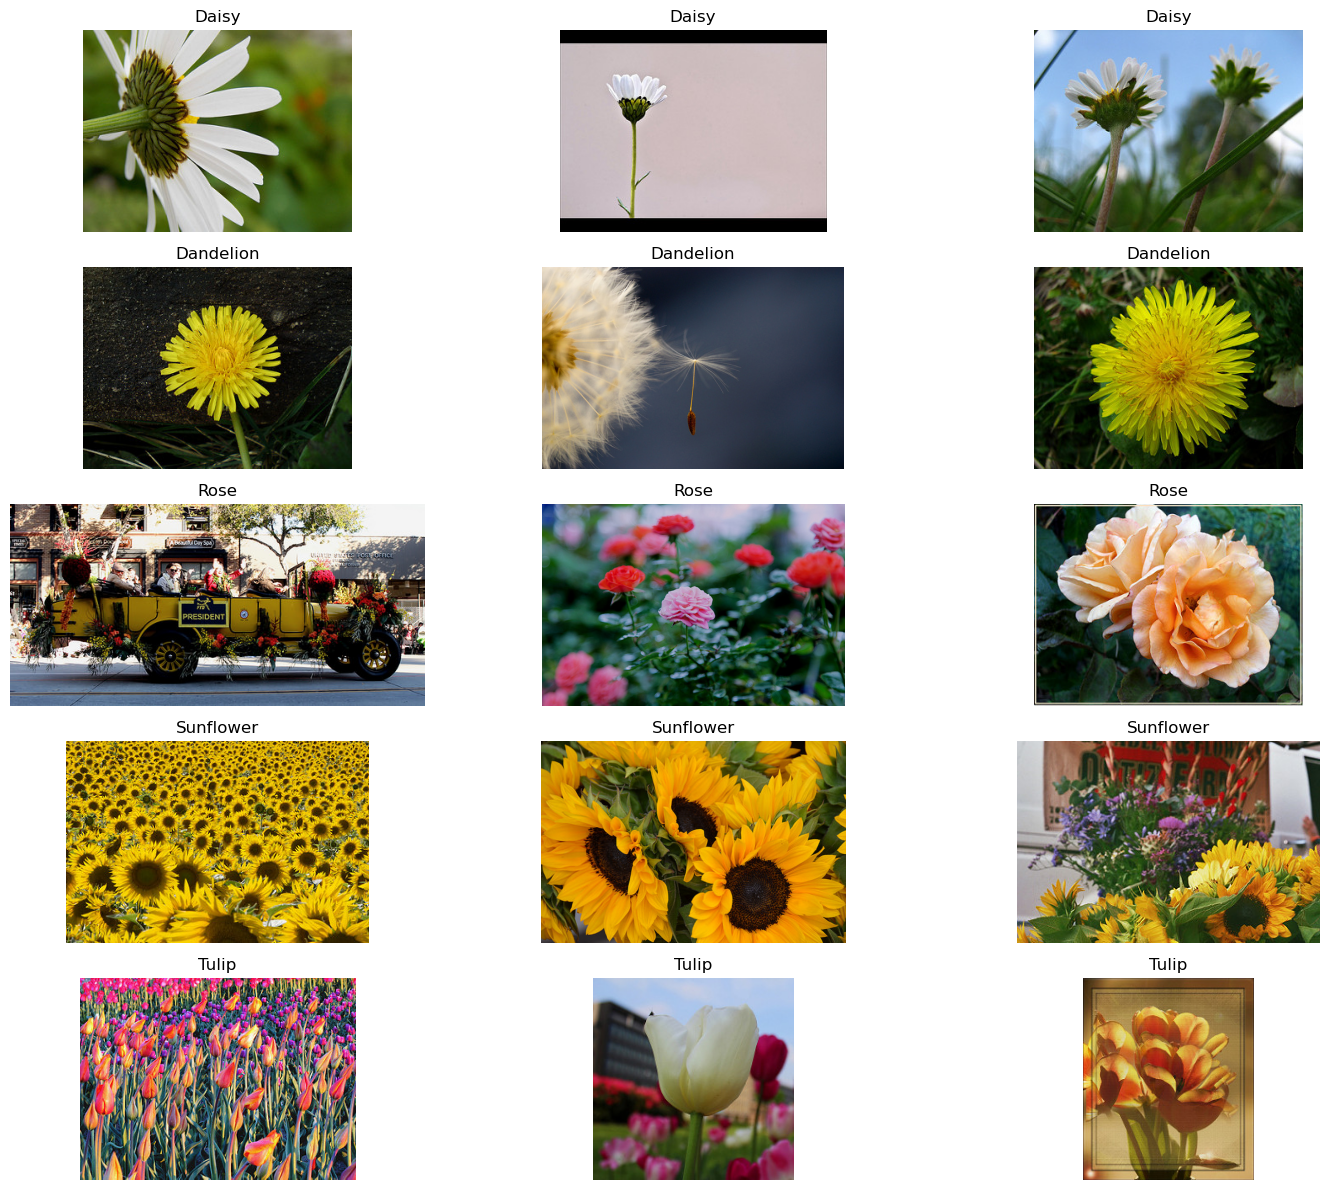

In [9]:
def show_flower_examples(data_dir='../data/flowers', num_examples=3):
    """Show examples from each flower type"""
    
    if IN_COLAB:
        data_dir = 'data/flowers'
    
    data_path = Path(data_dir)
    
    if not data_path.exists():
        print(f"❌ The folder {data_dir} does not exist!")
        return
    
    fig, axes = plt.subplots(num_classes, num_examples, figsize=(15, 12))
    
    for i, (class_name, class_idx) in enumerate(class_mapping.items()):
        class_dir = data_path / class_name
        
        if class_dir.exists():
            image_files = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
            
            for j in range(min(num_examples, len(image_files))):
                if j < len(image_files):
                    img_path = image_files[j]
                    img = Image.open(img_path)
                    
                    axes[i, j].imshow(img)
                    axes[i, j].set_title(f"{class_names[class_idx]}")
                    axes[i, j].axis('off')
                else:
                    axes[i, j].axis('off')
        else:
            for j in range(num_examples):
                axes[i, j].text(0.5, 0.5, 'Not found', ha='center', va='center')
                axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show examples
print("🌸 Examples from each flower type:")
show_flower_examples()

## Data Preprocessing

Before we can train the model, we need to prepare the data. This includes:
- **Normalization** of pixel values
- **Data augmentation** to increase variation
- **Splitting** into training, validation, and test sets

In [10]:
# Define transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Transformations defined!")
print("\n Training transformations:")
print("- Resize to 224x224")
print("- Random horizontal flip")
print("- Random rotation (±15°)")
print("- Color jitter")
print("- Normalization")

print("\n📋 Validation transformations:")
print("- Resize to 224x224")
print("- Normalization")
print("- No data augmentation")

✅ Transformations defined!

 Training transformations:
- Resize to 224x224
- Random horizontal flip
- Random rotation (±15°)
- Color jitter
- Normalization

📋 Validation transformations:
- Resize to 224x224
- Normalization
- No data augmentation


In [11]:
# Custom Dataset class
class FlowerDataset(Dataset):
    """Custom dataset for flower images"""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Load image
        image = Image.open(image_path).convert('RGB')
        
        # Apply transform
        if self.transform:
            image = self.transform(image)
            
        return image, label

print("✅ FlowerDataset class defined!")

✅ FlowerDataset class defined!


In [12]:
def prepare_data(data_dir='../data/flowers'):
    """Prepare data for training"""
    
    if IN_COLAB:
        data_dir = 'data/flowers'
    
    data_path = Path(data_dir)
    
    if not data_path.exists():
        print(f"❌ The folder {data_dir} does not exist!")
        return None, None, None, None
    
    # Collect all images and labels
    all_images = []
    all_labels = []
    
    for class_name, class_idx in class_mapping.items():
        class_dir = data_path / class_name
        
        if class_dir.exists():
            image_files = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
            
            for img_path in image_files:
                all_images.append(str(img_path))
                all_labels.append(class_idx)
    
    if not all_images:
        print("❌ No images found!")
        return None, None, None, None
    
    # Split into training, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(
        all_images, all_labels, test_size=0.3, random_state=RANDOM_SEED, stratify=all_labels
    )
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
    )
    
    print(f"  Data splitting complete:")
    print(f"  Training set: {len(X_train)} images")
    print(f"  Validation set: {len(X_val)} images")
    print(f"  Test set: {len(X_test)} images")
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), class_names

# Prepare data
train_data, val_data, test_data, class_names = prepare_data()

if train_data is not None:
    print("✅ Data prepared for training!")
else:
    print("❌ Could not prepare data")

  Data splitting complete:
  Training set: 2569 images
  Validation set: 550 images
  Test set: 551 images
✅ Data prepared for training!


In [13]:
# Create DataLoaders
if train_data is not None:
    X_train, y_train = train_data
    X_val, y_val = val_data
    X_test, y_test = test_data
    
    # Create datasets
    train_dataset = FlowerDataset(X_train, y_train, train_transform)
    val_dataset = FlowerDataset(X_val, y_val, val_transform)
    test_dataset = FlowerDataset(X_test, y_test, val_transform)
    
    # Create DataLoaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    print(f"✅ DataLoaders created with batch_size={batch_size}")
    print(f"  Training batches: {len(train_loader)}")
    print(f"  Validation batches: {len(val_loader)}")
    print(f"  Test batches: {len(test_loader)}")
else:
    print("❌ Could not create DataLoaders")

✅ DataLoaders created with batch_size=32
  Training batches: 81
  Validation batches: 18
  Test batches: 18


## 🏗️ CNN Architecture

Now we will build our CNN model. We start with a simple architecture and explain each component.

In [14]:
# =============================================================================
# CNN ARCHITECTURE FOR FLOWER CLASSIFICATION
# =============================================================================
# This CNN learns to classify flower images by extracting hierarchical features:
#   - Layer 1: Low-level features (edges, colors, textures)
#   - Layer 2: Mid-level features (petals, stems, patterns)
#   - Layer 3: High-level features (flower shapes, species characteristics)
#
# ARCHITECTURE OVERVIEW:
#   Input (3×224×224) → Conv1 → Pool → Conv2 → Pool → Conv3 → Pool 
#   → Flatten → FC1 → Dropout → FC2 → Output (5 classes)
#
# SAME ARCHITECTURE APPLIES TO MEDICAL IMAGING:
#   - Replace flower images with X-rays, MRI slices, histopathology
#   - Replace flower classes with disease states
#   - The CNN learns relevant features automatically!
# =============================================================================

class SimpleCNN(nn.Module):
    """
    Simple CNN for image classification (flowers or medical images).
    
    Architecture with tensor shapes:
        Input:  [batch, 3, 224, 224]   - RGB image
        Conv1:  [batch, 32, 112, 112]  - After conv + pool
        Conv2:  [batch, 64, 56, 56]    - After conv + pool
        Conv3:  [batch, 128, 28, 28]   - After conv + pool
        FC1:    [batch, 512]           - Compressed features
        Output: [batch, num_classes]   - Class scores
    """
    
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        
        # =================================================================
        # CONVOLUTIONAL LAYERS (Feature Extraction)
        # =================================================================
        # Conv1: RGB input (3 channels) → 32 feature maps
        # Detects low-level features: edges, colors, simple textures
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        
        # Conv2: 32 → 64 feature maps
        # Combines low-level features into mid-level patterns
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # Conv3: 64 → 128 feature maps
        # Learns high-level, class-specific features
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # =================================================================
        # POOLING (Downsampling)
        # =================================================================
        # Reduces spatial dimensions by half (2×2 max pooling)
        # Also provides some translation invariance
        self.pool = nn.MaxPool2d(2, 2)
        
        # =================================================================
        # REGULARIZATION
        # =================================================================
        # Dropout: randomly disables 50% of neurons during training
        # Prevents overfitting by forcing redundant representations
        self.dropout = nn.Dropout(0.5)
        
        # =================================================================
        # FULLY CONNECTED LAYERS (Classification)
        # =================================================================
        # FC1: Compress spatial features into 512 features
        # Input size: 128 channels × 28 × 28 = 100,352 (after 3 pooling layers)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        
        # FC2: Map 512 features to class scores
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        """
        Forward pass: extract features and classify.
        
        Args:
            x: Input image tensor [batch, 3, 224, 224]
        
        Returns:
            Logits for each class [batch, num_classes]
        """
        # === Convolutional feature extraction ===
        # Block 1: Conv → ReLU → Pool
        x = self.pool(torch.relu(self.conv1(x)))  # 224→112
        
        # Block 2: Conv → ReLU → Pool
        x = self.pool(torch.relu(self.conv2(x)))  # 112→56
        
        # Block 3: Conv → ReLU → Pool
        x = self.pool(torch.relu(self.conv3(x)))  # 56→28
        
        # === Flatten: 3D feature maps → 1D vector ===
        x = x.view(-1, 128 * 28 * 28)
        
        # === Classification ===
        x = torch.relu(self.fc1(x))   # Compress to 512 features
        x = self.dropout(x)           # Regularization (training only)
        x = self.fc2(x)               # Class scores (logits)
        
        return x

print("✅ SimpleCNN class defined!")

✅ SimpleCNN class defined!


In [15]:
# Create model
model = SimpleCNN(num_classes=num_classes)
model = model.to(device)

# Display model architecture
print("🏗️ Model Architecture:")
print("=" * 50)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Device: {device}")

🏗️ Model Architecture:
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=5, bias=True)
)

 Parameters:
  Total: 51,476,549
  Trainable: 51,476,549
  Device: mps


### 🔍 Explanation of CNN Components

**Convolutional Layers (Conv2d):**
- Detect patterns such as edges, textures, shapes
- Each filter learns to recognize specific features
- First layer: 3 input channels (RGB) → 32 feature maps

**Pooling (MaxPool2d):**
- Reduces image size
    - 224×224 → 112×112 → 56×56 → 28×28
- Retains important features, reduces noise
- Makes the model more robust to small shifts

**Activation Function (ReLU):**
- ReLU(x) = max(0, x)
- Introduces non-linearity
    - Without ReLU the model would be linear
- Helps learn complex patterns

**Fully Connected Layers:**
- Combines all features into a prediction
- fc1: 128×28×28 = 100,352 → 512
- fc2: 512 → 5 (number of classes)

**Dropout:**
- Regularization to prevent overfitting
- Randomly turns off 50% of neurons during training

### ✅ Check Your Understanding: CNN Architecture

**Q1:** Why do we use multiple convolutional layers instead of just one?

<details>
<summary>Click for answer</summary>

**Answer:** Multiple layers enable **hierarchical feature learning**:

| Layer | What It Learns | Example (Flowers) | Example (Medical) |
|-------|---------------|-------------------|-------------------|
| **Conv1** | Low-level features | Edges, colors | Tissue boundaries |
| **Conv2** | Mid-level patterns | Petal shapes | Organ structures |
| **Conv3** | High-level concepts | Flower types | Disease patterns |

A single layer could only learn simple patterns. Stacking layers allows the network to compose simple features into complex, class-specific representations.
</details>

**Q2:** What is the purpose of pooling layers?

<details>
<summary>Click for answer</summary>

**Answer:** Pooling serves multiple purposes:

1. **Dimensionality reduction:** 224×224 → 112×112 → 56×56 → 28×28
2. **Translation invariance:** Small shifts in the input don't change the output
3. **Computational efficiency:** Fewer parameters in subsequent layers
4. **Larger receptive field:** Each neuron "sees" a larger portion of the original image

**Max pooling** specifically keeps the strongest activations, which often correspond to the most important features.
</details>

**Q3:** Why is the same CNN architecture applicable to both flowers and medical images?

<details>
<summary>Click for answer</summary>

**Answer:** The CNN is a **general-purpose feature extractor**:

- It learns whatever features are useful for the classification task
- No hard-coded rules about "what a flower looks like" or "what disease looks like"
- The training data determines what features are learned

**Key differences in practice:**
- Medical images may be grayscale (1 channel vs 3)
- Medical datasets are often smaller (need regularization, augmentation)
- Medical applications require higher reliability and explainability
</details>

> 🏥 **Medical AI Connection:** The same CNN principles apply to X-ray classification, histopathology analysis, and MRI interpretation. The architecture is a tool - the data and labels define the task.

---

## 💾 Saving Model and Data

Before we proceed to training, we save the model and data so they can be used in part 2.

In [16]:
# Save model architecture and data
if train_data is not None:
    # Save model architecture
    torch.save(model.state_dict(), 'flower_model_architecture.pth')
    
    # Save data splitting
    import pickle
    data_info = {
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'X_test': X_test,
        'y_test': y_test,
        'class_names': class_names,
        'class_mapping': class_mapping,
        'num_classes': num_classes
    }
    
    with open('flower_data_info.pkl', 'wb') as f:
        pickle.dump(data_info, f)
    
    print("✅ Model and data saved for part 2!")
    print("📁 Files created:")
    print("  - flower_model_architecture.pth")
    print("  - flower_data_info.pkl")
else:
    print("❌ Could not save - no data available")

✅ Model and data saved for part 2!
📁 Files created:
  - flower_model_architecture.pth
  - flower_data_info.pkl


---

## 📚 Glossary of Key Terms

### CNN Components

| Term | Definition |
|------|------------|
| **Convolution** | Sliding a filter across an image to detect patterns |
| **Feature map** | Output of a convolutional layer - where patterns were detected |
| **Filter/Kernel** | Small weight matrix (e.g., 3×3) that detects specific patterns |
| **Flatten** | Reshape 3D tensor to 1D vector for fully connected layers |
| **Max pooling** | Take maximum value in each window (downsampling) |
| **Padding** | Adding zeros around image edges to preserve spatial dimensions |
| **ReLU** | Rectified Linear Unit: max(0, x) - introduces non-linearity |
| **Stride** | Step size when sliding the filter |

### Training & Data

| Term | Definition |
|------|------------|
| **Batch size** | Number of images processed together before weight update |
| **DataLoader** | PyTorch utility for batching, shuffling, and loading data |
| **Data augmentation** | Creating variations of images (flip, rotate, crop) |
| **Epoch** | One complete pass through the training dataset |
| **Transform** | Image preprocessing operation (resize, normalize, augment) |

### Hardware & Environment

| Term | Definition |
|------|------------|
| **CPU** | Central Processing Unit - general-purpose processor |
| **CUDA** | NVIDIA's parallel computing platform for GPUs |
| **GPU** | Graphics Processing Unit - parallel processor for deep learning |
| **MPS** | Metal Performance Shaders - Apple Silicon GPU acceleration |
| **Tensor** | N-dimensional array (PyTorch's core data structure) |

## Summary and Next Steps

### What we have accomplished:
- ✅ Set up the environment (CPU/GPU/MPS)
- ✅ Downloaded and explored the flower dataset
- ✅ Prepared data with transformations and splitting
- ✅ Built a CNN model from scratch
- ✅ Saved model and data for part 2

### Next steps (part 2):
- Training the model
- Visualization of training results
- Saving the trained model

### Reflection questions:
1. **Why** do we use convolutional layers instead of regular fully connected layers?
2. **How** does data augmentation affect model performance?
3. **What** are the benefits of splitting data into training, validation, and test sets?
4. **Why** is normalization important for CNN training?

---

**Continue to part 2: `C2-cnn-training.ipynb`**

---

## 📖 Further Reading & Resources

### CNN Fundamentals

| Resource | Description |
|----------|-------------|
| **CS231n: CNNs for Visual Recognition** | Stanford's comprehensive CNN course |
| **3Blue1Brown: Neural Networks** | Beautiful visual explanations |
| **PyTorch Tutorials** | Official documentation and examples |
| **"Deep Learning" (Goodfellow et al.)** | Chapter 9 covers CNNs in depth |

### Medical Image Analysis

| Resource | Description |
|----------|-------------|
| **MONAI** | Medical Open Network for AI - PyTorch for healthcare |
| **fastMONAI** | High-level API for medical imaging deep learning |
| **Papers With Code - Medical** | Latest medical imaging papers with code |

### Key Takeaways

```
┌──────────────────────────────────────────────────────────────────────────┐
│                   CNN ARCHITECTURE PIPELINE                              │
├──────────────────────────────────────────────────────────────────────────┤
│                                                                          │
│  Input      →   Conv Layers   →   Pooling   →   FC Layers   →   Output   │
│  (Image)        (Features)        (Reduce)      (Classify)      (Class)  │
│                                                                          │
│  WHAT EACH COMPONENT DOES:                                               │
│  ─────────────────────────                                               │
│  • Convolution: Detect patterns (edges, textures, shapes)                │
│  • ReLU: Introduce non-linearity (allow complex functions)               │
│  • Pooling: Reduce dimensions, add translation invariance                │
│  • Dropout: Prevent overfitting (regularization)                         │
│  • FC layers: Combine features for classification                        │
│                                                                          │
└──────────────────────────────────────────────────────────────────────────┘
```

**You now understand:**
- ✅ How CNNs extract hierarchical features from images
- ✅ Setting up PyTorch for different hardware (CPU/GPU/MPS)
- ✅ Loading and preprocessing image datasets
- ✅ Building a CNN architecture from scratch
- ✅ How the same architecture applies to flowers and medical images

---

*Next: C2 - Training and evaluating the CNN on the flower dataset!*